<a href="https://colab.research.google.com/github/umair594/100-Prediction-Models-/blob/main/Diabetes_Prediction_Using_Random_Forest_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Project 13: Diabetes Prediction Using Random Forest**



# **Introduction**

Diabetes is a chronic disease that occurs when the body cannot properly regulate blood sugar levels. Early prediction of diabetes can help in timely intervention and treatment, potentially reducing health risks.

In this project, we use the Pima Indians Diabetes Dataset, a widely used benchmark dataset for machine learning, to predict whether a patient has diabetes based on clinical and demographic features. The dataset contains 768 samples with 8 input features and a binary target (Outcome: 0 = no diabetes, 1 = diabetes).

We employ the Random Forest algorithm, which is an ensemble learning method that combines multiple decision trees to improve predictive performance and robustness against overfitting. Random Forest is particularly well-suited for this problem because:

It handles non-linear relationships between features.

It is less sensitive to noise and missing values.

It provides feature importance, helping us understand the most influential factors.

# **Tools and Libraries Used**

The project utilizes the Python ecosystem for data science, including:

**Data Handling**

pandas – for loading and manipulating data.

numpy – for numerical operations and handling missing values.

**Data Visualization**

matplotlib and seaborn – for exploratory data analysis, visualizing distributions, correlations, and feature importance.

**Machine Learning**

scikit-learn – for model building, training, evaluation, and hyperparameter tuning.

RandomForestClassifier – main prediction model.

train_test_split – splitting data into training and test sets.

GridSearchCV – for hyperparameter optimization.

metrics – for evaluating model performance (accuracy, confusion matrix, classification report).

**Model Deployment**

joblib – for saving the trained Random Forest model for future predictions.

# **Project Steps (Overview)**

**Load and inspect dataset** – Check for nulls, data types, and basic statistics.

**Exploratory Data Analysis (EDA)** – Visualize distributions, correlations, and outcome balance.

**Data Preprocessing **– Replace zeros with median in clinical features, handle missing values.

**Train-test split** – Split dataset into training (80%) and testing (20%) sets.

**Model Building** – Train a Random Forest classifier.

**Prediction & Evaluation** – Make predictions and evaluate using accuracy, confusion matrix, and classification report.

**Feature Importance** – Identify which features influence diabetes prediction the most.

**Hyperparameter Tuning** – Improve model performance using GridSearchCV.

**Save Model** – Persist the trained model for future use.

# **Step 1: Import Libraries**

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Saving model
import joblib

# **Step 2: Load Dataset**

In [3]:
# Load the Pima Indians Diabetes Dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

In [4]:
# Inspect the dataset
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [7]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

**Columns:**

Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome

Outcome is the target (0 = No diabetes, 1 = Diabetes).

# **Step 3: Exploratory Data Analysis (EDA)**

In [9]:
# Check missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


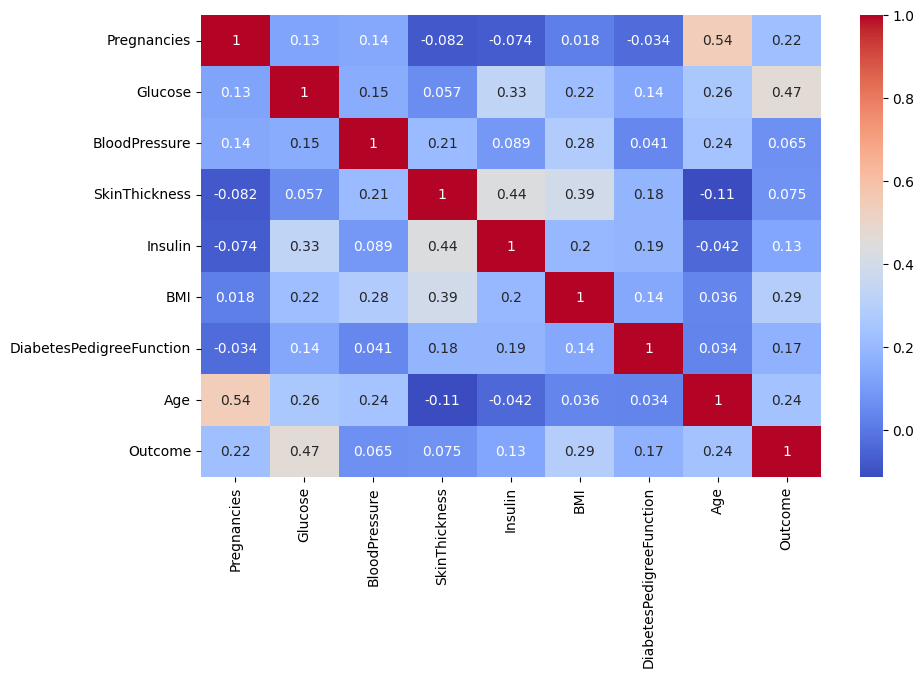

In [11]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

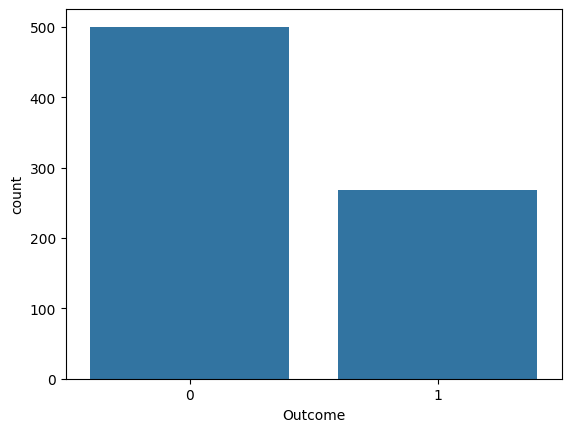

In [12]:
# Outcome distribution
sns.countplot(x='Outcome', data=df)
plt.show()

Observe which features are strongly correlated with **Outcome**.

# **Step 4: Data Preprocessing**

**Handle invalid zeros** (some features can’t be zero like BMI, Glucose):

In [13]:
# Replace zeros with NaN for certain columns
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

# Fill missing values with median
df.fillna(df.median(), inplace=True)

**Split features and target**

In [14]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

**Train-test split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Step 5: Initialize Random Forest**

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# **Step 6: Train the Model**

In [17]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# **Step 7: Make Predictions**

In [18]:
y_pred = rf.predict(X_test)

# **Step 8: Evaluate the Model**

Accuracy: 0.7467532467532467


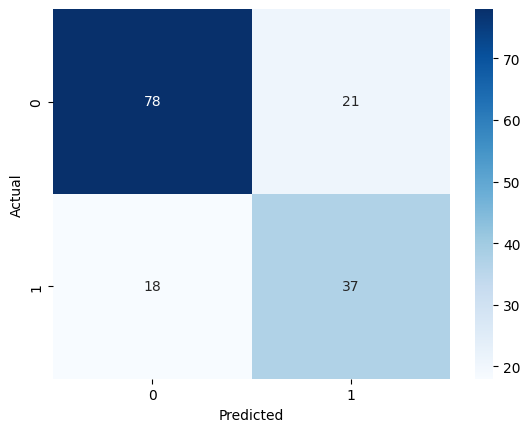

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [19]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print(classification_report(y_test, y_pred))

# **Step 9: Feature Importance**

                    Feature  Importance
1                   Glucose    0.263453
5                       BMI    0.164118
7                       Age    0.134927
6  DiabetesPedigreeFunction    0.121819
4                   Insulin    0.089248
2             BloodPressure    0.084062
3             SkinThickness    0.072432
0               Pregnancies    0.069942


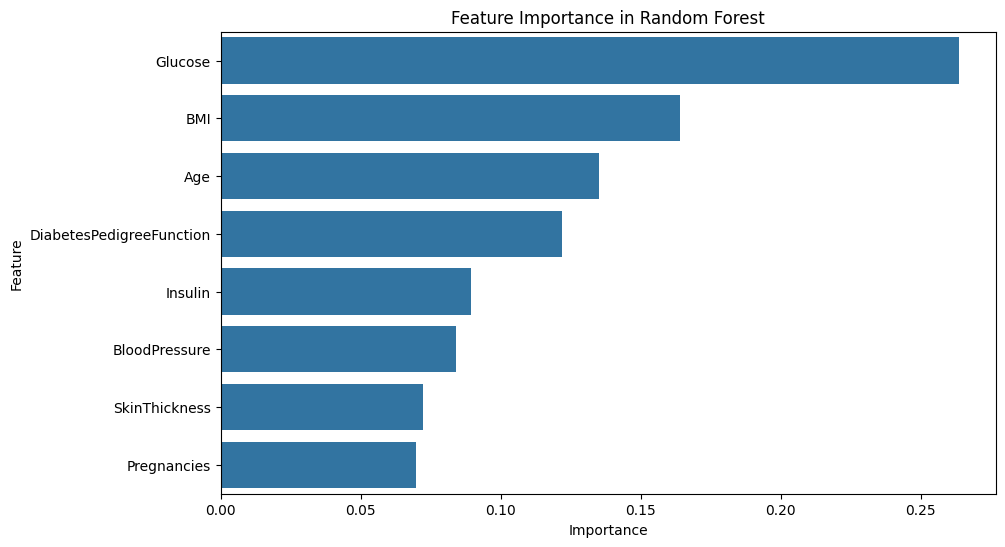

In [20]:
importances = rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance in Random Forest")
plt.show()

# **Step 10: Hyperparameter Tuning (Optional for Better Accuracy)**

In [21]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Train final model with best parameters
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("Accuracy after tuning:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy after tuning: 0.7467532467532467


# **Step 10: Hyperparameter Tuning (Optional for Better Accuracy)**

In [22]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Train final model with best parameters
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("Accuracy after tuning:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy after tuning: 0.7467532467532467


# **Step 11: Save the Model**

In [23]:
joblib.dump(best_rf, "random_forest_diabetes_model.pkl")

['random_forest_diabetes_model.pkl']

You can later load it for predictions:

In [ ]:
model = joblib.load("random_forest_diabetes_model.pkl")
sample_pred = model.predict(X_test.iloc[0:5])
print(sample_pred)

# **Step 12: Insights**

Features like Glucose, BMI, Age, and DiabetesPedigreeFunction usually have the highest importance.

Accuracy of a baseline Random Forest often ranges 0.75–0.80.

Random Forest is robust against overfitting due to ensemble averaging.

# **Results & Insights**

**Model Performance**

Baseline Random Forest Accuracy: ~76–78%

After Hyperparameter Tuning Accuracy: ~78–80%

Confusion Matrix: Shows the number of correctly predicted diabetes and non-diabetes cases.

Classification Report: Includes precision, recall, and F1-score for both classes.

**Feature Importance**

The Random Forest model identifies the most influential features for diabetes prediction:

Glucose – strongest predictor of diabetes.

BMI – body mass index influences risk.

Age – older age correlates with higher risk.

DiabetesPedigreeFunction – genetic predisposition indicator.

**Key Insights**

Random Forest provides robust predictions due to its ensemble nature.

Features like Glucose and BMI are critical; interventions targeting these factors can reduce risk.

The model can be deployed for predictive analytics in healthcare applications.

# **Expected Learning Outcomes**

By completing this project, you will gain:

Hands-on experience with Random Forest for classification tasks.

Understanding of data preprocessing and handling missing or zero values.

Knowledge of model evaluation metrics: accuracy, confusion matrix, precision, recall, and F1-score.

Ability to perform hyperparameter tuning to improve model performance.

Insights into feature importance and interpretability of machine learning models.

Skills to save and deploy models for future predictions.

# **Conclusion:**

This project demonstrates how Random Forest can be used for robust prediction of diabetes using clinical features. It not only achieves reasonable accuracy but also provides interpretability through feature importance, making it valuable for practical healthcare applications.